<a href="https://colab.research.google.com/github/syifaymd/Pratikum-Analisis-Deret-Waktu/blob/main/Tugas_Minggu_2_Kecenderungan_Deret_Syifa_Ul_Qalbi_YMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [56]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1026)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 13
beta0 = 36
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


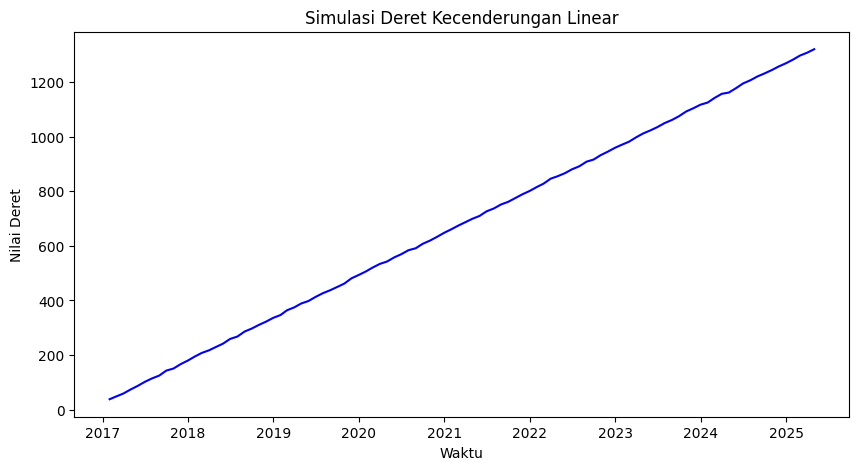

In [57]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

**Jawaban:**
Terdapat korelasi yang kuat antar pengamatan (autokorelasi) pada deret tersebut. Hal ini terlihat dari grafik yang menunjukkan tren linear positif yang konsisten dari tahun 2017 hingga 2025 dan hampir membentuk garis lurus tanpa fluktuasi acak yang berarti. Pola tersebut menunjukkan bahwa nilai pengamatan pada suatu waktu memiliki keterkaitan yang kuat dengan nilai pengamatan pada waktu sebelumnya. Dengan demikian, deret tersebut tidak bersifat acak atau independen, melainkan memiliki ketergantungan antarwaktu yang kuat. Selain itu, adanya tren linear yang jelas mengindikasikan bahwa deret tidak bersifat stasioner, karena karakteristik rata-rata data berubah seiring waktu. Pengamatan yang berdekatan juga menunjukkan korelasi serial yang sangat tinggi.

In [58]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [59]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.605e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.53e-225
Time:                        16:59:41   Log-Likelihood:                -208.98
No. Observations:                 100   AIC:                             422.0
Df Residuals:                      98   BIC:                             427.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           36.2436      0.392     92.406   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

**Jawaban:**
Hasil pengepasan model regresi menghasilkan $\hat{\beta}_0 = 36{.}24$ dan $\hat{\beta}_1 = 12{.}996$, yang sangat dekat dengan nilai parameter asli yang digunakan dalam pembangkitan data, yaitu $\beta_0 = 36$ dan $\beta_1 = 13$. Perbedaan kecil antara nilai estimasi dan parameter asli disebabkan oleh adanya galat acak (noise) yang ditambahkan dalam proses simulasi.

Model menghasilkan nilai $R^2 = 1{.}000$ dan F-statistic sebesar $3{.}61 \times 10^{6}$ dengan p-value yang sangat kecil, mendekati $0$ (sekitar $1{.}5 \times 10^{-225}$), yang menunjukkan bahwa variabel waktu (`Time_Numeric`) mampu menjelaskan hampir seluruh variasi nilai deret. Selain itu, koefisien $\hat{\beta}_1$ sangat signifikan secara statistik dengan p-value $<0{.}001$, sehingga terdapat bukti yang sangat kuat adanya hubungan linear positif antara waktu dan nilai deret. Nilai Durbin-Watson sebesar $1{.}943$ yang mendekati 2 juga menunjukkan bahwa residual tidak mengalami autokorelasi yang kuat. Dengan demikian, model regresi linear yang dipaskan sudah baik dan sesuai untuk menangkap pola kecenderungan linear yang sangat kuat pada deret waktu tersebut, serta menghasilkan estimasi parameter yang sangat dekat dengan nilai parameter asli.



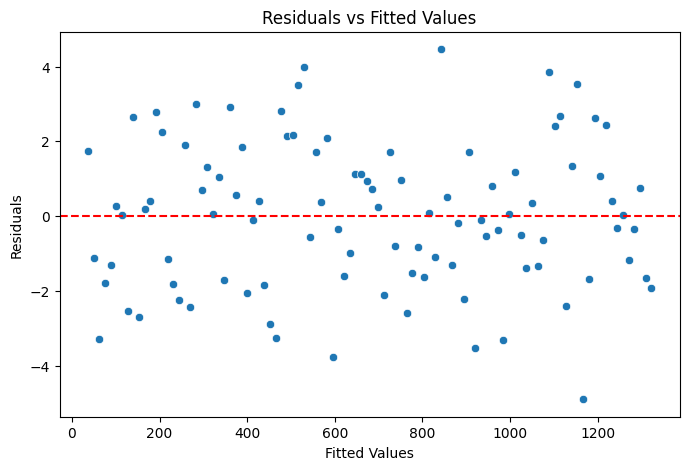

In [60]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

**Jawaban:**
Plot residual terhadap nilai fitted menunjukkan bahwa titik-titik residual tersebar secara acak di sekitar garis nol dan tidak membentuk pola sistematis tertentu. Tidak terlihat pola melengkung maupun pola berbentuk corong (funnel-shaped). Hal ini menunjukkan bahwa asumsi linearitas terpenuhi karena model telah mampu menangkap hubungan linear antara variabel waktu dan nilai deret. Selain itu, sebaran residual yang relatif seragam di sepanjang nilai fitted menunjukkan bahwa asumsi homoskedastisitas, yaitu ragam residual yang konstan, juga terpenuhi. Dengan demikian, secara visual tidak terdapat indikasi pelanggaran asumsi linearitas dan homoskedastisitas pada model regresi.

In [61]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.9631


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

**Jawaban:**
Uji Breusch-Pagan menghasilkan p-value $\approx 0{.}96$, yang lebih besar dari taraf signifikansi $\alpha = 0{.}05$. Oleh karena itu, $H_0$ gagal ditolak, sehingga tidak terdapat cukup bukti untuk menyatakan adanya heteroskedastisitas pada residual model. Dengan demikian, varians residual dapat dianggap konstan atau asumsi homoskedastisitas terpenuhi. Hasil ini konsisten dengan plot residual terhadap fitted value sebelumnya yang menunjukkan sebaran residual relatif acak dan tidak membentuk pola tertentu.

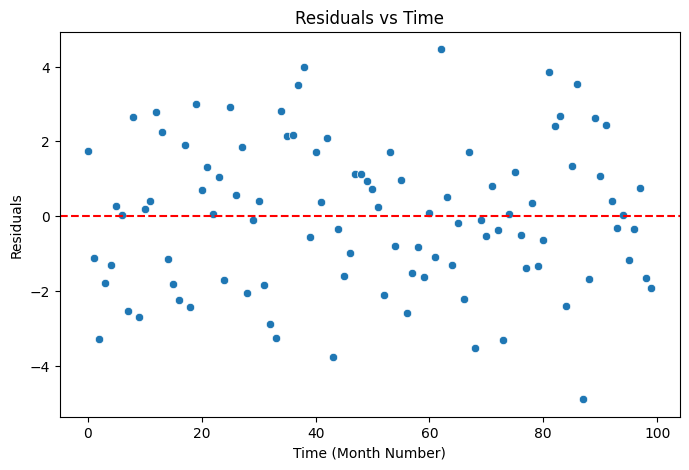

In [62]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

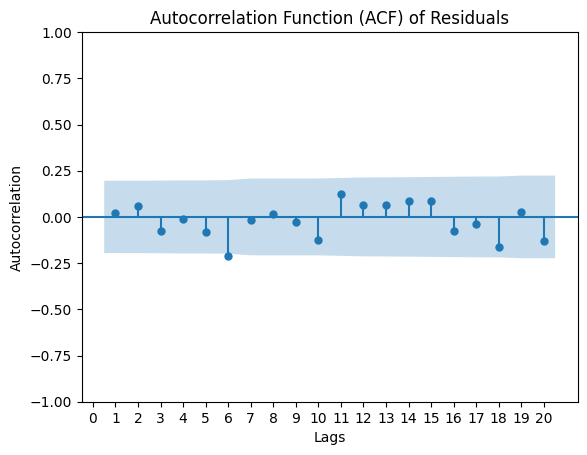

In [63]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

**Jawaban:**
Pada plot ACF residual, hampir seluruh nilai autokorelasi pada lag 1 hingga 20 berada di dalam selang kepercayaan di sekitar nol dan tidak menunjukkan adanya lonjakan yang mencolok maupun pola peluruhan yang sistematis. Hal ini menunjukkan bahwa tidak terdapat indikasi autokorelasi yang kuat pada residual di berbagai lag. Dengan demikian, komponen tren linear yang digunakan dalam model telah mampu menangkap pola ketergantungan waktu pada deret asli dengan baik, sehingga residual yang dihasilkan cenderung bersifat acak atau mendekati white noise. Hasil ini juga mendukung bahwa model regresi yang dipaskan telah mampu menangkap struktur utama dari deret waktu tersebut.


In [64]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.039593   0.842278
2    0.387252   0.823966
3    0.992121   0.803159
4    1.006666   0.908784
5    1.713954   0.887137
6    6.667964   0.352648
7    6.696051   0.461198
8    6.716236   0.567535
9    6.808280   0.657072
10   8.516578   0.578511
11  10.222566   0.510485
12  10.676081   0.556863
13  11.185067   0.595317
14  12.084179   0.599543
15  12.922322   0.608298
16  13.627730   0.626425
17  13.829688   0.679119
18  17.194773   0.509754
19  17.301079   0.569478


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

**Jawaban:**
Uji Ljung-Box pada berbagai lag, yaitu lag 1 hingga 19, menghasilkan p-value yang lebih besar dari taraf signifikansi $\alpha = 0{.}05$ pada seluruh lag yang diuji. Sebagai contoh, p-value sebesar $\approx 0{.}84$ pada lag 1, $\approx 0{.}89$ pada lag 5, $\approx 0{.}58$ pada lag 10, dan $\approx 0{.}57$ pada lag 19. Karena p-value $> \alpha$, maka $H_0$ gagal ditolak, yang menunjukkan bahwa tidak terdapat cukup bukti adanya autokorelasi residual hingga lag ke-$k$. Dengan demikian, secara formal tidak terdapat bukti autokorelasi yang signifikan pada residual, sehingga asumsi independensi residual dapat dianggap terpenuhi. Hasil ini konsisten dengan plot ACF residual yang sebelumnya menunjukkan bahwa nilai autokorelasi berada dalam selang kepercayaan.

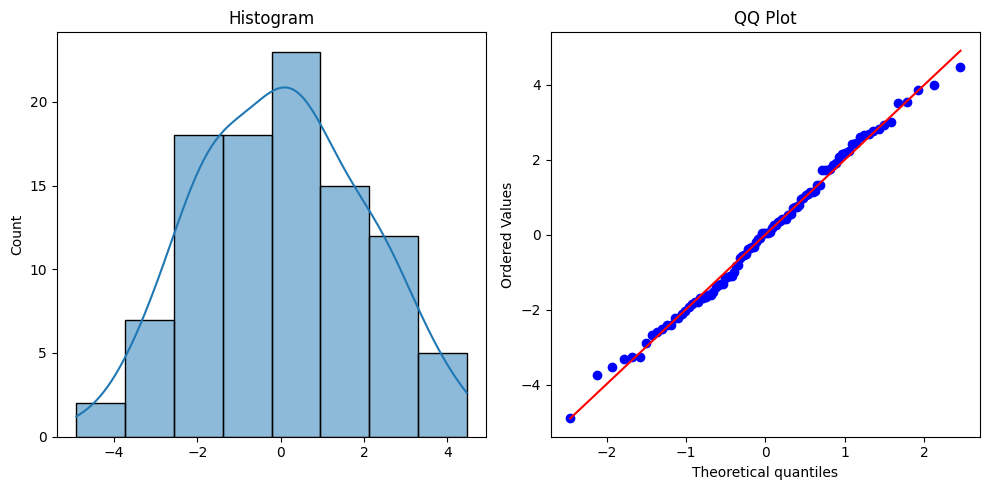

In [65]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

**Jawaban:** Histogram residual menunjukkan bentuk sebaran yang relatif simetris dan menyerupai bentuk lonceng, tanpa adanya kemencengan (*skewness*) yang ekstrem. Selanjutnya, QQ-plot menunjukkan bahwa sebagian besar titik residual terbakukan berada di sekitar garis referensi normal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Secara visual, kedua plot tersebut menunjukkan bahwa residual cenderung mengikuti distribusi normal. Dengan demikian, secara visual tidak terdapat indikasi kuat adanya pelanggaran asumsi normalitas residual. Namun, kesimpulan tersebut perlu dikonfirmasi melalui uji formal, seperti uji Shapiro-Wilk.


In [66]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.992339589251072, p-value = 0.8452496648956451


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

**Jawaban:**
Ya, hasil uji Shapiro-Wilk konsisten dengan kesimpulan berdasarkan plot. Uji Shapiro-Wilk menghasilkan p-value $\approx 0{.}845$, yang jauh lebih besar dari taraf signifikansi $\alpha = 0{.}05$. Oleh karena itu, $H_0$ gagal ditolak, sehingga tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Hasil uji formal ini sejalan dengan histogram dan QQ-plot yang sebelumnya menunjukkan bahwa residual cenderung mengikuti distribusi normal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi. Jika digabungkan dengan hasil pemeriksaan linearitas, homoskedastisitas, dan non-autokorelasi sebelumnya, tidak terdapat indikasi kuat adanya pelanggaran asumsi klasik OLS pada model regresi yang dipaskan. Oleh karena itu, model regresi linear tersebut dapat dikatakan sesuai untuk menggambarkan kecenderungan linear pada deret waktu ini.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [67]:
# Menentukan parameter simulasi
np.random.seed(1026)
n_periods = 120
beta_0, beta_1, beta_2= 76, 13, 0.52
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

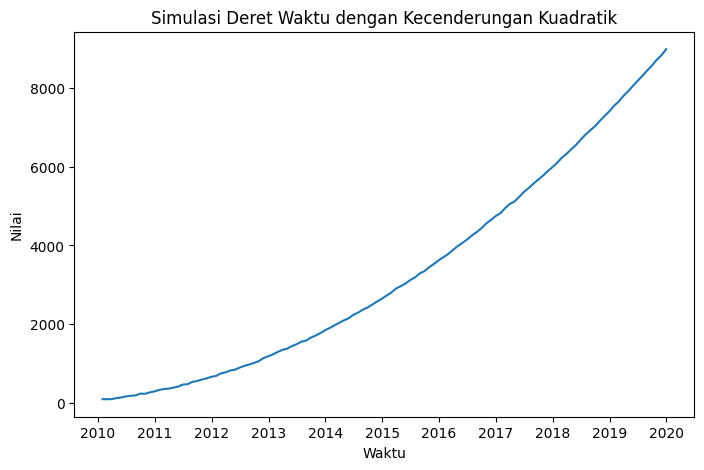

In [68]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**Jawaban:**
Plot deret dengan kecenderungan kuadratik menunjukkan pola kurva yang melengkung ke atas (parabolik), dengan nilai deret meningkat semakin cepat seiring bertambahnya waktu. Pola ini berbeda dengan deret yang memiliki kecenderungan linear, di mana perubahan nilai relatif konstan sehingga pola pengamatan membentuk garis lurus. Pada kecenderungan kuadratik, laju perubahan nilai tidak konstan, melainkan semakin besar seiring waktu akibat adanya komponen kuadrat waktu, yaitu $t^2$. Oleh karena itu, deret menunjukkan hubungan yang nonlinear terhadap waktu, sehingga pola tersebut lebih tepat digambarkan menggunakan model regresi kuadratik dibandingkan regresi linear sederhana.

In [69]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.529e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.00e-286
Time:                        16:59:42   Log-Likelihood:                -440.87
No. Observations:                 120   AIC:                             887.7
Df Residuals:                     117   BIC:                             896.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.0950      2.601     29.639      0.0

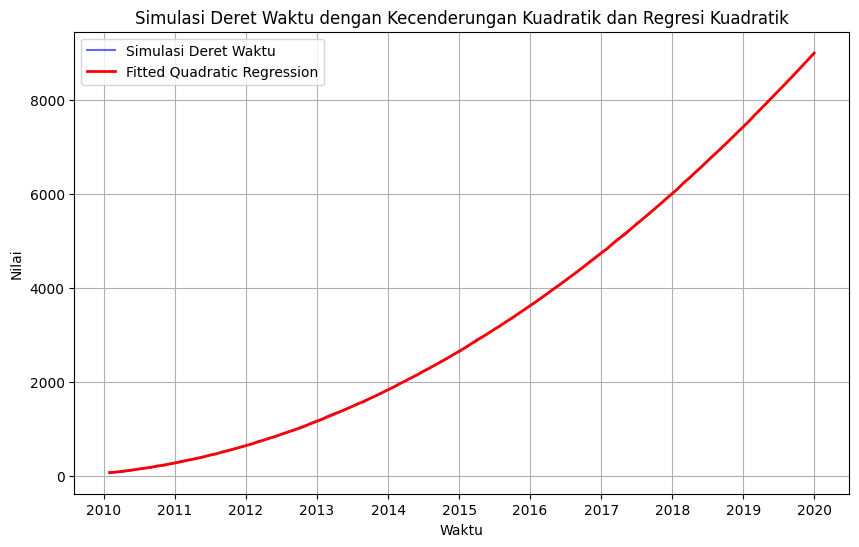

In [70]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

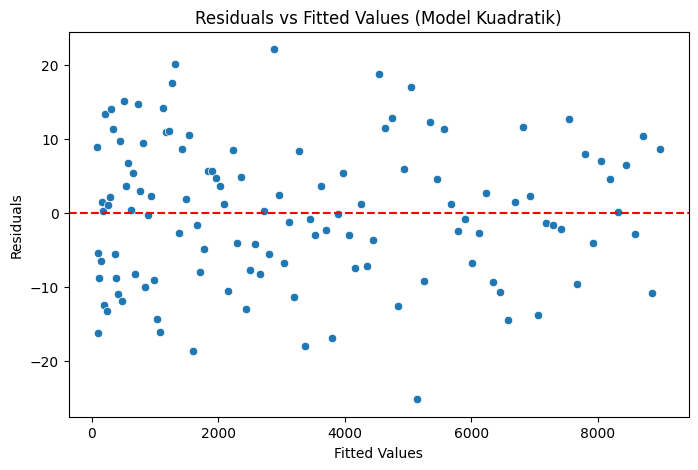

P-value Breusch-Pagan Test (Kuadratik): 0.5469


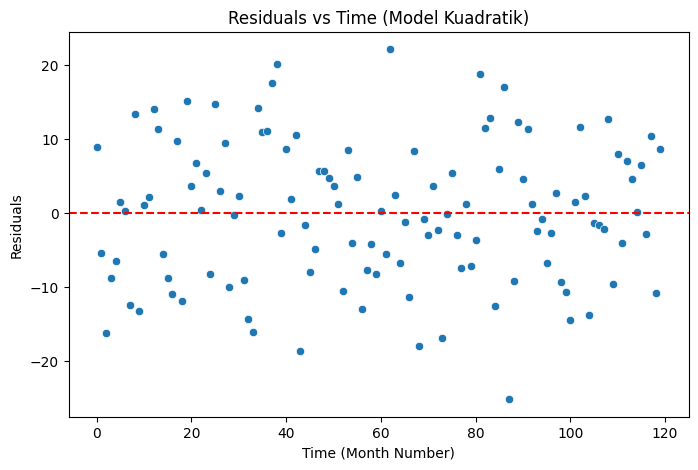

<Figure size 800x500 with 0 Axes>

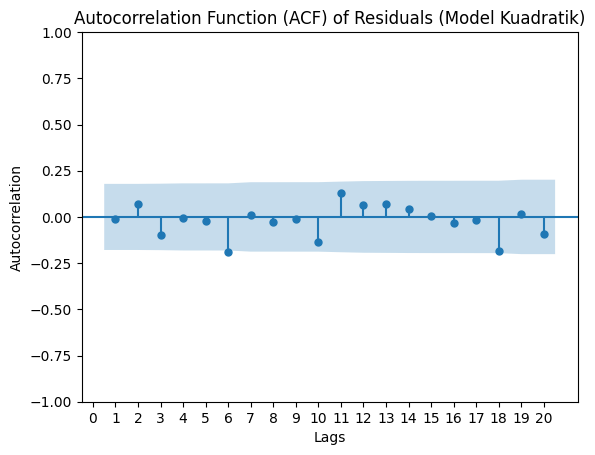

Ljung-Box Test p-value (Kuadratik):
      lb_stat  lb_pvalue
1    0.015968   0.899443
2    0.652369   0.721672
3    1.898223   0.593797
4    1.903646   0.753475
5    1.962045   0.854372
6    6.523577   0.367158
7    6.531896   0.479187
8    6.647929   0.575050
9    6.662325   0.672229
10   9.068846   0.525583
11  11.320570   0.416811
12  11.898237   0.453887
13  12.574436   0.481194
14  12.813227   0.541280
15  12.814822   0.616598
16  12.982970   0.674003
17  13.018446   0.734950
18  17.836736   0.466456
19  17.884524   0.530164


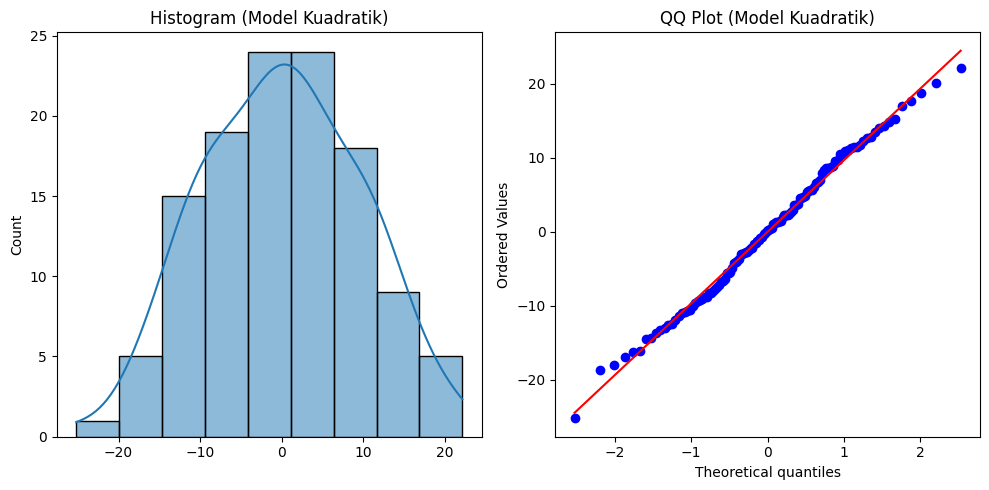

Shapiro-Wilk Test (Kuadratik): Statistics = 0.9931746392644242, p-value = 0.8268672846649578


In [71]:
# cek asumsi model regresi kuadratik
# 1. Residual vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Model Kuadratik)")
plt.show()

# 2. Uji Breusch-Pagan (homoskedastisitas)
bp_test_quad = het_breuschpagan(model_quad.resid, model_quad.model.exog)
print(f"P-value Breusch-Pagan Test (Kuadratik): {bp_test_quad[1]:.4f}")

# 3. Residual vs Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=time, y=model_quad.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time (Model Kuadratik)")
plt.show()

# 4. Plot ACF residual
plt.figure(figsize=(8, 5))
plot_acf(model_quad.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals (Model Kuadratik)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

# 5. Uji Ljung-Box (non-autokorelasi)
ljung_box_test_quad = acorr_ljungbox(model_quad.resid, lags=range(1,20), return_df=True)
print("Ljung-Box Test p-value (Kuadratik):")
print(ljung_box_test_quad)

# 6. Histogram dan QQ-Plot residual
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram (Model Kuadratik)')
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Model Kuadratik)')
plt.tight_layout()
plt.show()

# 7. Uji Shapiro-Wilk (normalitas)
shapiro_stat_quad, shapiro_p_quad = stats.shapiro(model_quad.resid)
print(f"Shapiro-Wilk Test (Kuadratik): Statistics = {shapiro_stat_quad}, p-value = {shapiro_p_quad}")


**Jawaban:**
Berdasarkan pengecekan terhadap residual vs fitted, uji Breusch-Pagan, ACF dan uji Ljung-Box, histogram/QQ-plot, serta uji Shapiro-Wilk, diperoleh hasil sebagai berikut:

- Linearitas terhadap variabel $t$ dan $t^2$:
Plot residual vs fitted menunjukkan titik-titik residual tersebar secara acak di sekitar nol dan tidak membentuk pola sistematis. Hal ini menunjukkan bahwa model kuadratik telah cukup mampu menangkap struktur rata-rata data.
- Homoskedastisitas:
Uji Breusch-Pagan menghasilkan p-value $\approx 0{.}55$ > $\alpha$($0{.}05$). Oleh karena itu, $H_0$ gagal ditolak, sehingga tidak terdapat cukup bukti adanya heteroskedastisitas. Dengan demikian, ragam residual dapat dianggap homogen atau konstan.
- Non autokorelasi:
Plot ACF menunjukkan bahwa sebagian besar nilai autokorelasi berada dalam selang kepercayaan. Selain itu, uji Ljung-Box menghasilkan p-value yang tinggi pada seluruh lag yang diuji, yaitu lebih besar dari 0,5. Oleh karena itu, $H_0$ gagal ditolak, sehingga tidak terdapat cukup bukti adanya autokorelasi pada residual.
- Normalitas:
Histogram dan QQ-plot menunjukkan bahwa residual cenderung mengikuti pola distribusi normal. Hasil ini diperkuat oleh uji Shapiro-Wilk yang menghasilkan p-value $\approx 0{.}83$ > $\alpha$(0.05). Oleh karena itu, $H_0$ gagal ditolak dan tidak terdapat cukup bukti bahwa residual tidak berdistribusi normal.
- **Kesimpulan:**
Berdasarkan seluruh pemeriksaan tersebut, tidak terdapat indikasi kuat adanya pelanggaran terhadap asumsi regresi klasik. Asumsi linearitas, homoskedastisitas, non-autokorelasi, dan normalitas residual dapat dianggap terpenuhi. Dengan demikian, model regresi kuadratik yang dipaskan sudah tepat dan mampu menggambarkan pola data dengan baik. Hal ini masuk akal karena data memiliki pola kecenderungan yang melengkung, sehingga komponen $t^2$ dalam model dapat menangkap perubahan laju pertumbuhan nilai deret yang tidak konstan.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [72]:
# Menentukan parameter simulasi
np.random.seed(1026)
n_periods = 120
beta0, beta1, beta2=76,-650, -52
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


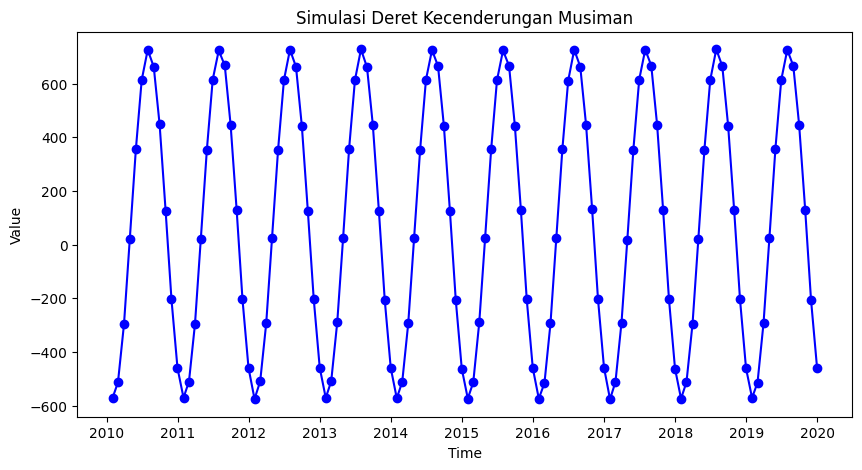

In [73]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

**Jawaban:**
Berdasarkan grafik, deret waktu menunjukkan pola musiman yang sangat jelas dan berulang secara periodik dengan periode 12 bulan. Amplitudo osilasinya sangat besar: nilai deret berfluktuasi dari sekitar $-576$ hingga $728$, dengan puncak muncul di pertengahan tahun (sekitar Juni-Juli) dan lembah muncul di awal tahun (Januari-Februari). Pola naik-turun ini berulang secara konsisten pada waktu yang sama setiap tahun.

Tidak terlihat adanya kecenderungan (tren) jangka panjang yang signifikan, karena posisi puncak dan lembah relatif stabil sepanjang periode pengamatan (tidak bergeser naik ataupun turun dari tahun ke tahun). Dengan demikian, dapat disimpulkan bahwa komponen musiman merupakan faktor dominan yang memengaruhi pola deret waktu tersebut, dengan pola musiman tahunan (periode 12 bulan) yang sangat kuat dan konsisten.

In [74]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [75]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [76]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [77]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.462e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          9.60e-255
Time:                        16:59:43   Log-Likelihood:                -240.55
No. Observations:                 120   AIC:                             505.1
Df Residuals:                     108   BIC:                             538.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -573.3691      0.599   -957.646      0.0

Bagaimana interpretasi dari hasil tersebut?

**Jawaban:**
Model regresi tanpa intersep dengan 12 peubah dummy bulan digunakan untuk mengidentifikasi pola musiman pada deret waktu. Karena model tidak menggunakan intersep, koefisien masing-masing dummy menunjukkan estimasi rata-rata nilai deret pada bulan tersebut. Hasil regresi dengan 120 observasi menunjukkan nilai R-squared sebesar 1.000 dan Adjusted R-squared sebesar 1.000, sehingga model memiliki tingkat kecocokan yang sangat tinggi dalam menjelaskan variasi data. Model juga signifikan secara statistik, yang ditunjukkan oleh F-statistic sebesar 6.462 × 10⁵ dengan p-value sebesar 9.60 × 10⁻²⁵⁵ < 0.05. Selain itu, seluruh peubah dummy bulan memiliki p-value sebesar 0.000 < 0.05, sehingga seluruh bulan menunjukkan pengaruh yang signifikan dalam model. Berdasarkan nilai koefisien, terlihat adanya pola musiman yang jelas. Nilai deret meningkat dari Januari sebesar −573.37 hingga mencapai nilai tertinggi pada Juli sebesar 726.16, kemudian mengalami penurunan hingga Desember sebesar −460.18. Dengan demikian, Juli merupakan periode dengan nilai rata-rata tertinggi, sedangkan Januari merupakan periode dengan nilai rata-rata terendah, dengan selisih sekitar 1299.53 satuan. Selanjutnya, nilai Durbin-Watson sebesar 2.046 yang mendekati 2 menunjukkan bahwa tidak terdapat indikasi autokorelasi residual yang kuat. Hasil uji normalitas juga menunjukkan p-value Omnibus sebesar 0.456 dan p-value Jarque-Bera sebesar 0.528, yang keduanya lebih besar dari 0.05, sehingga residual dapat dianggap tidak menunjukkan penyimpangan yang signifikan dari normalitas. Secara keseluruhan, hasil regresi menunjukkan bahwa deret waktu memiliki pola musiman yang sangat kuat, dengan kecenderungan meningkat dari Januari hingga Juli dan menurun kembali dari Juli hingga Desember.

In [78]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

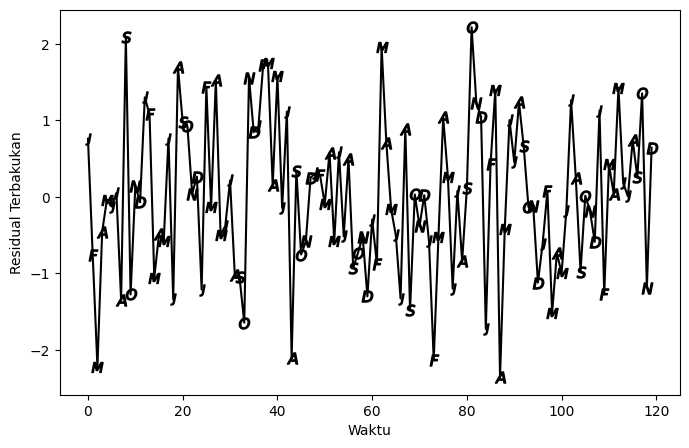

In [79]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


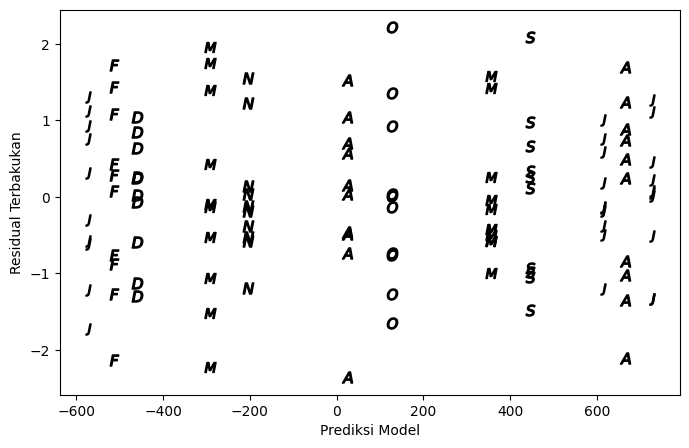

In [80]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

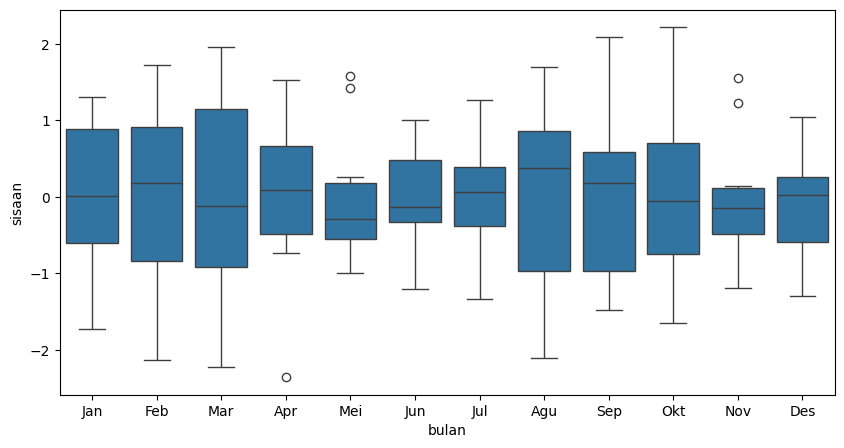

In [81]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

**Jawaban:**
Berdasarkan ketiga plot, sisaan terlihat tersebar di sekitar nilai nol dan tidak menunjukkan pola tertentu terhadap waktu maupun nilai prediksi. Hal ini menunjukkan bahwa tidak terdapat pola sistematis yang kuat pada sisaan dan pola musiman dalam data telah cukup baik ditangkap oleh model.

Pada boxplot sisaan berdasarkan bulan, median sisaan pada sebagian besar bulan berada di sekitar nol. Terdapat beberapa observasi dengan sisaan terbakukan yang relatif besar (|sisaan| > 2), terutama pada bulan Februari, Maret, April, Agustus, September, dan Oktober. Selain itu, terdapat perbedaan sebaran sisaan antarbulan, tetapi tidak menunjukkan pola penyimpangan yang sistematis.

Secara keseluruhan, ketiga plot menunjukkan bahwa sisaan cenderung bersifat acak dan model telah cukup baik dalam menangkap pola musiman. Meskipun terdapat beberapa observasi dengan sisaan agak besar dan perbedaan sebaran antarbulan, tidak terlihat pola sistematis yang kuat, sehingga model dapat dikatakan cukup memadai dalam menggambarkan pola data.

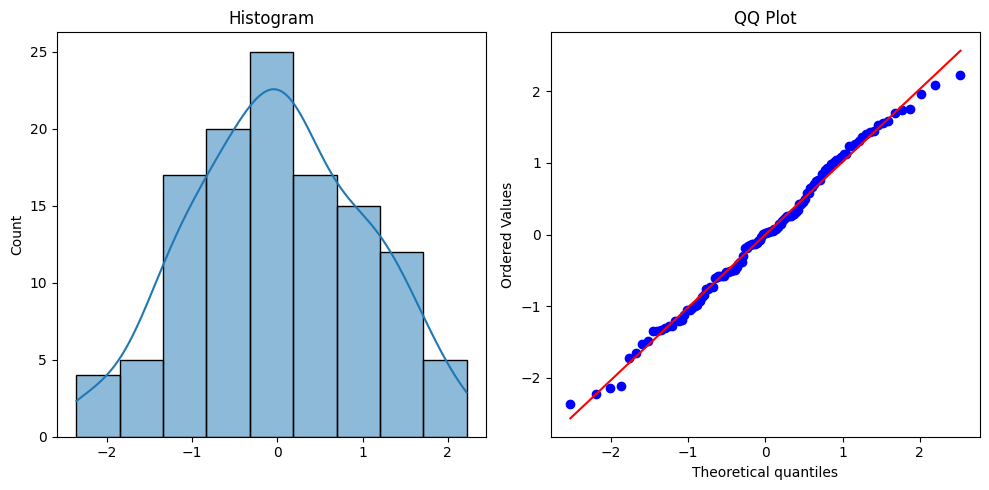

In [82]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

**Jawaban:**
Berdasarkan histogram dan QQ plot, sisaan terlihat mendekati distribusi normal karena sebagian besar titik pada QQ plot berada di sekitar garis diagonal dan histogram berpusat di sekitar nol. Jika hasil uji formal menunjukkan nilai p-value lebih besar dari 0.05, maka asumsi normalitas, homoskedastisitas, dan independensi sisaan dapat dianggap terpenuhi. Dengan demikian, model yang dipasang dapat dikatakan cukup tepat dalam menangkap pola musiman pada data.

In [83]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [84]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [85]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.462e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          9.60e-255
Time:                        16:59:46   Log-Likelihood:                -240.55
No. Observations:                 120   AIC:                             505.1
Df Residuals:                     108   BIC:                             538.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -573.3691      0.599   -957.646      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?



**Jawaban:**

Kedua model menghasilkan nilai fitted value, $R^2$ ($1.000$), dan sisaan yang identik — keduanya sebenarnya adalah *reparameterisasi* dari model yang sama, hanya berbeda cara penulisan koefisiennya:

- Pada model tanpa intersep, tiap koefisien dummy bulan ($\hat\beta_{Jan}, \hat\beta_{Feb}, \dots$) langsung menyatakan rata-rata (level) nilai deret pada bulan tersebut. Misalnya $\hat\beta_{Jan}\approx -573{.}37$ berarti rata-rata deret di bulan Januari adalah $-573{.}37$.

- Pada model dengan intersep, salah satu bulan (Januari) dijadikan kategori acuan (baseline) dan menjadi nilai konstanta ($\hat\beta_0 \approx -573{.}37$, sama seperti $\hat\beta_{Jan}$ pada model tanpa intersep). Koefisien bulan lainnya (Februari, Maret, ...) menyatakan selisih rata-rata bulan tersebut terhadap bulan acuan (Januari). Contoh: koefisien Maret $\approx 280{.}28$ berarti rata-rata nilai deret di bulan Maret lebih tinggi $280{.}28$ satuan dibanding bulan Januari ($-573{.}37+280{.}28=-293{.}09$, sama dengan estimasi langsung Maret pada model tanpa intersep).

Jadi, model dengan intersep lebih menekankan perbandingan antar bulan relatif terhadap baseline, sedangkan model tanpa intersep langsung memberi level rata-rata tiap bulan. Keduanya secara matematis ekuivalen (fit dan prediksi sama persis).

**Apakah asumsi terpenuhi?** Ya, karena sisaan model dengan intersep identik dengan sisaan model tanpa intersep, hasil uji asumsi juga sama persis: Breusch-Pagan p-value $\approx 0{.}29$, Shapiro-Wilk p-value $\approx 0{.}63$, dan Ljung-Box p-value $\approx 0{.}76$ pada lag 1 — semuanya $> 0{.}05$, sehingga homoskedastisitas, non-autokorelasi, dan normalitas sisaan tetap terpenuhi.

In [86]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [87]:
# Parameter
np.random.seed(1026)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 13, 260 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


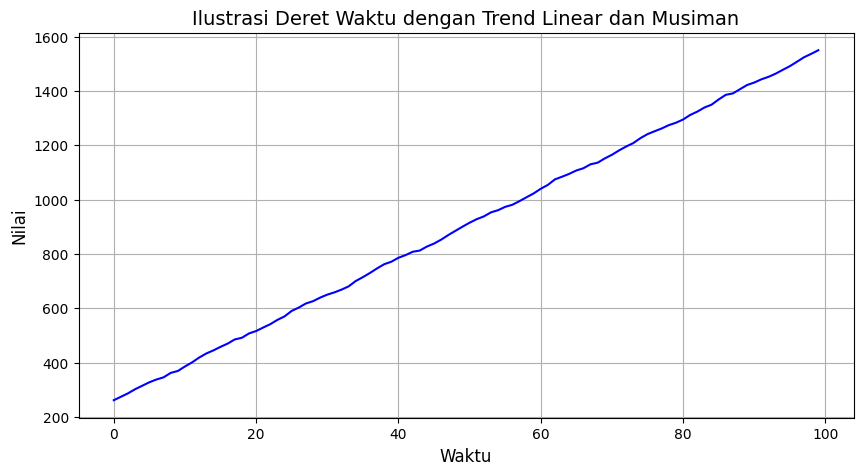

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [89]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [90]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [91]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.014e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.18e-195
Time:                        16:59:46   Log-Likelihood:                -202.84
No. Observations:                 100   AIC:                             431.7
Df Residuals:                      87   BIC:                             465.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      260.5999      0.735    354.565      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

**Jawaban:**
Model regresi menggunakan 12 peubah dummy bulan dan variabel period tanpa intersep diterapkan untuk mengestimasi tren dan pola musiman pada deret waktu. Karena model tidak menggunakan intersep, koefisien masing-masing dummy bulan merepresentasikan nilai dasar deret pada bulan tersebut ketika period = 0, sedangkan perbedaan nilai koefisien antarbulan menunjukkan adanya variasi musiman. Sebagai contoh, koefisien Januari sebesar 260.60 menunjukkan estimasi nilai dasar deret pada bulan Januari, sedangkan koefisien Maret sebesar 265.40 menunjukkan estimasi nilai dasar pada bulan Maret ketika period = 0. Koefisien period sebesar 12.9959 menunjukkan adanya tren peningkatan linear, yaitu setiap kenaikan satu periode menyebabkan nilai deret meningkat sekitar 13 satuan, yang sangat mendekati nilai parameter simulasi $\beta_1=13$. Dengan demikian, model mampu menangkap kecenderungan peningkatan nilai deret dari waktu ke waktu sekaligus mempertahankan perbedaan nilai antarbulan sebagai komponen musiman. Seluruh koefisien dalam model memiliki p-value sebesar 0.000 < 0.05, sehingga baik efek bulan maupun tren waktu dinyatakan signifikan secara statistik. Selain itu, nilai R-squared sebesar 1.000 dan Adjusted R-squared sebesar 1.000 menunjukkan bahwa model memiliki tingkat kecocokan yang sangat tinggi dan mampu menjelaskan hampir seluruh variasi data. Nilai Durbin-Watson sebesar 1.984 yang mendekati 2 juga menunjukkan tidak adanya indikasi autokorelasi residual yang kuat. Berdasarkan hasil tersebut, dapat disimpulkan bahwa model regresi berhasil menggambarkan deret waktu dengan sangat baik melalui kombinasi tren linear yang meningkat sekitar 13 satuan setiap periode dan pola musiman yang relatif kecil antarbulan.

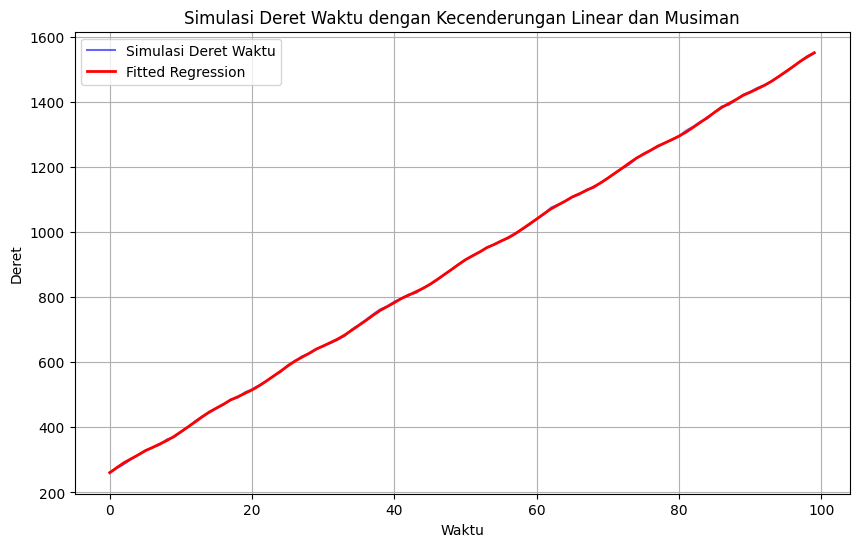

In [92]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

**Jawaban:**
Berdasarkan pengecekan asumsi:
- **Homoskedastisitas (Breusch-Pagan):** p-value $\approx 0{.}26$ (> 0,05) → gagal tolak $H_0$, ragam sisaan homogen, tidak ada pelanggaran.
- **Non-autokorelasi (ACF & Ljung-Box):** nilai ACF pada berbagai lag berada dalam selang kepercayaan dan uji Ljung-Box menghasilkan p-value tinggi di semua lag (misalnya $\approx 0{.}97$ pada lag 1, $\approx 0{.}67$ pada lag 19) → gagal tolak $H_0$, tidak ada pelanggaran autokorelasi.
- **Normalitas (Shapiro-Wilk):** p-value $\approx 0{.}69$ (> 0,05) → gagal tolak $H_0$, sisaan menyebar normal, tidak ada pelanggaran.

**Kesimpulan:** model regresi gabungan (dummy bulan + variabel waktu linear) yang menangkap tren sekaligus musiman ini tidak menunjukkan pelanggaran asumsi klasik regresi. Semua asumsi (linearitas, homoskedastisitas, non-autokorelasi, normalitas) terpenuhi, sehingga model sudah tepat digunakan untuk deret dengan komponen tren dan musiman sekaligus.

In [93]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [94]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

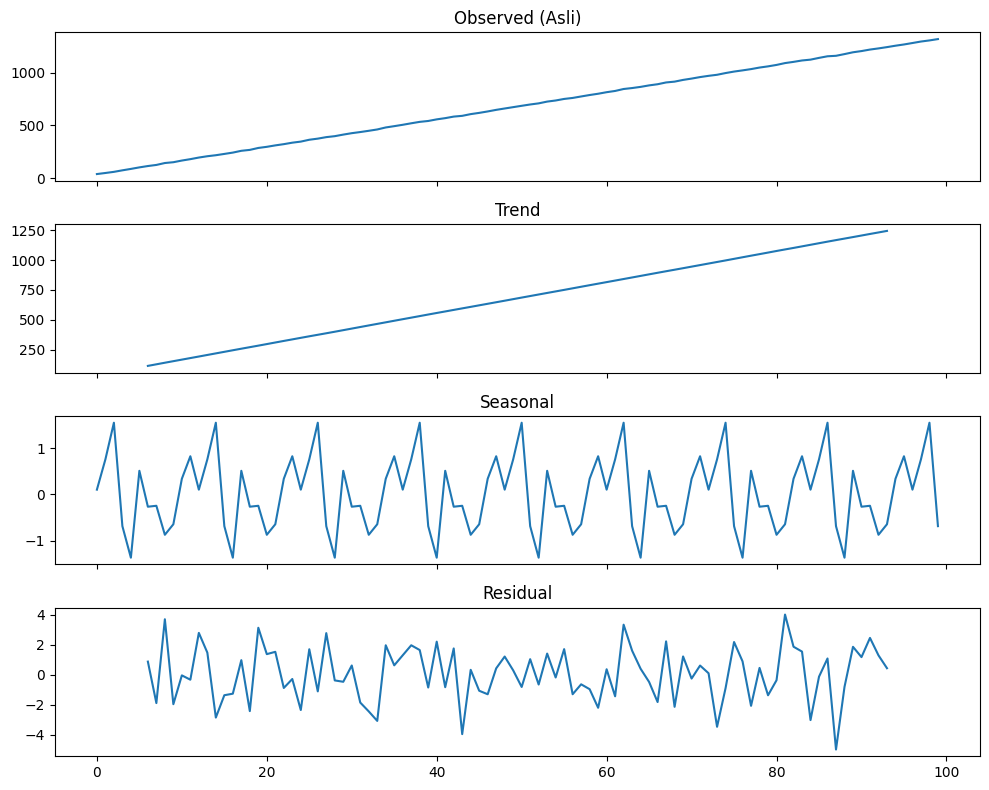

In [95]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawaban:**
Hasil dekomposisi terhadap deret dengan kecenderungan linear menunjukkan bahwa komponen trend mengikuti pola peningkatan yang hampir linear dan menjadi komponen yang paling dominan dalam deret. Komponen seasonal menunjukkan pola berulang dengan amplitudo yang relatif kecil, sehingga tidak menunjukkan adanya komponen musiman yang kuat. Pola tersebut kemungkinan merupakan variasi kecil akibat fluktuasi acak dalam data. Sementara itu, komponen residual berfluktuasi secara acak di sekitar nilai nol tanpa menunjukkan pola tertentu.

**Kesimpulan** : deret waktu dipengaruhi oleh tren linear, sedangkan pengaruh musiman relatif kecil dan residual merepresentasikan variasi acak yang tidak dapat dijelaskan oleh komponen trend dan seasonal.

In [96]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

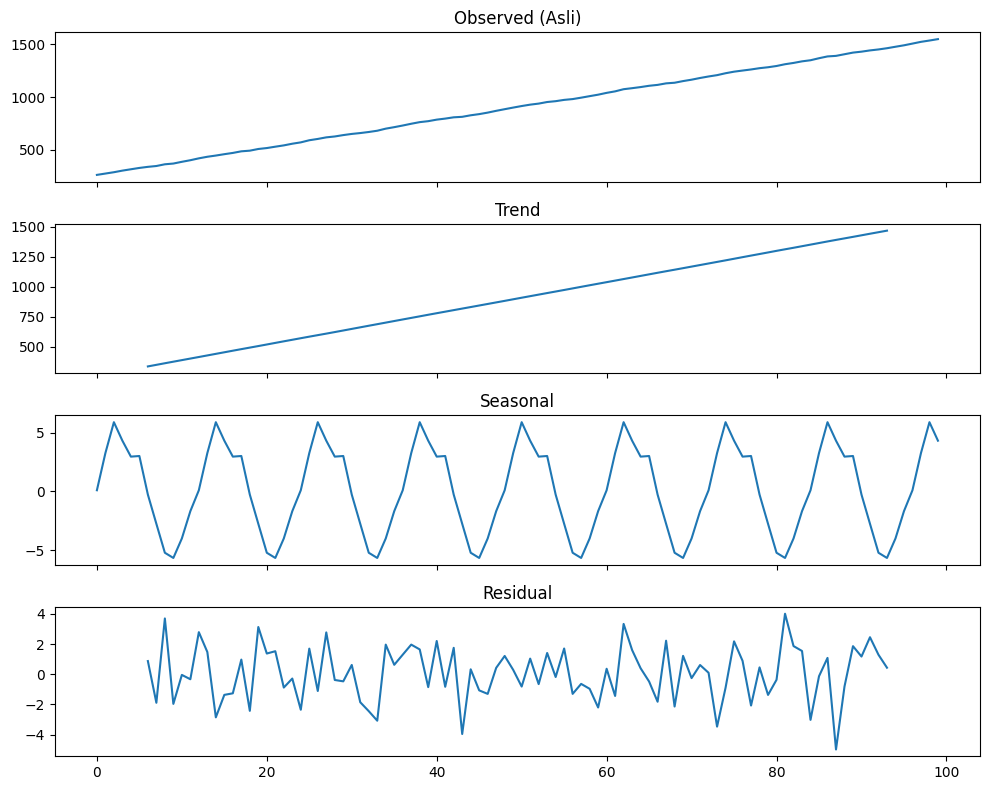

In [97]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawaban**
Berdasarkan hasil dekomposisi deret waktu,
- Komponen trend menunjukkan pola peningkatan yang konsisten dan hampir linear sepanjang periode pengamatan. Hal ini menunjukkan adanya kecenderungan peningkatan nilai deret dari waktu ke waktu dan sesuai dengan karakteristik komponen tren linear yang digunakan dalam pembangkitan data.

- Komponen seasonal menunjukkan pola yang berulang secara teratur setiap 12 periode dengan amplitudo sekitar ±5 hingga ±6 satuan. Pola tersebut membentuk gelombang yang konsisten dari satu periode ke periode berikutnya, sehingga menunjukkan adanya komponen musiman yang cukup kuat. Bentuk pola ini juga sesuai dengan komponen sinusoidal yang terdapat dalam deret, dengan nilai musiman mencapai puncak dan lembah secara berkala.

- komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis tertentu. Fluktuasi residual berada pada kisaran sekitar -5 hingga 4 satuan dan mencerminkan variasi acak atau noise yang tidak dapat dijelaskan oleh komponen tren dan musiman.

Dengan demikian, hasil dekomposisi berhasil memisahkan tiga komponen utama deret, yaitu tren linear, pola musiman dengan periode 12, dan variasi acak. Komponen tren dan musiman terlihat jelas pada data, sedangkan residual relatif acak. Hal ini menunjukkan bahwa dekomposisi mampu menggambarkan struktur utama deret waktu dengan baik.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [98]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1026)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 1.3, 260 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

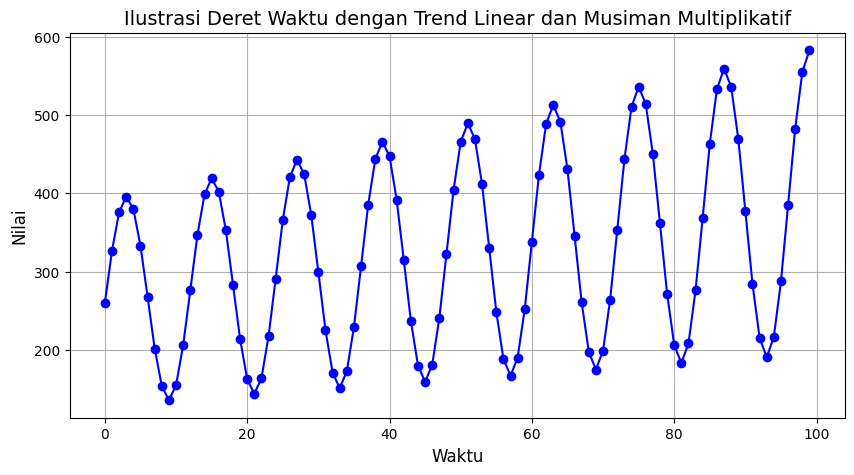

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [100]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

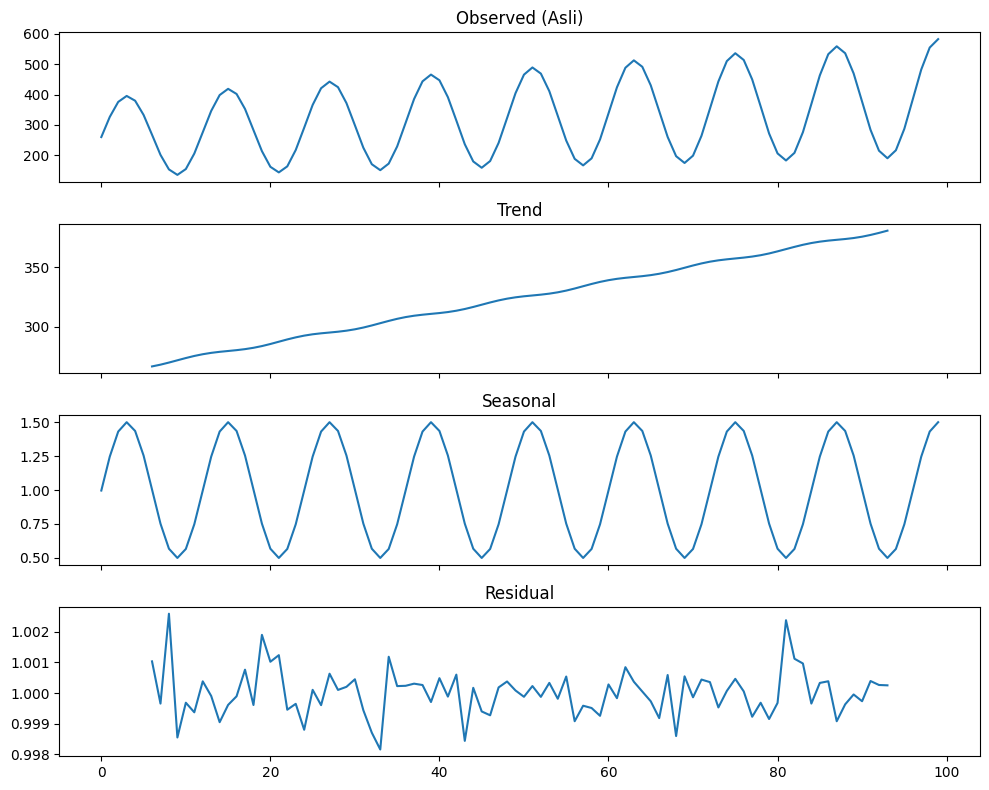

In [101]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

**Jawaban**
Berdasarkan hasil dekomposisi, deret waktu menunjukkan pola multiplikatif, yaitu pengaruh musiman berubah secara proporsional terhadap tingkat tren. Hal ini terlihat pada plot Observed, di mana amplitudo fluktuasi musiman semakin besar seiring dengan meningkatnya nilai deret.

Komponen trend menunjukkan kecenderungan meningkat secara konsisten dari waktu ke waktu. Sementara itu, komponen seasonal berada pada kisaran sekitar 0.50 hingga 1.50 dan membentuk pola yang berulang setiap 12 periode. Nilai tersebut merupakan faktor pengali, sehingga pada periode tertentu nilai deret dapat menjadi sekitar 1.5 kali tingkat trennya, sedangkan pada periode lainnya dapat turun menjadi sekitar 0.5 kali tingkat trennya.

Komponen residual berfluktuasi di sekitar nilai 1, yang merupakan karakteristik dekomposisi multiplikatif. Nilai residual yang mendekati 1 menunjukkan bahwa sebagian besar variasi sistematis pada data telah dijelaskan oleh komponen trend dan seasonal.

Dengan demikian, hasil dekomposisi menunjukkan bahwa model multiplikatif sesuai untuk deret tersebut. Hal ini disebabkan oleh amplitudo pola musiman yang meningkat seiring de

In [102]:
# Parameter
np.random.seed(1026)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

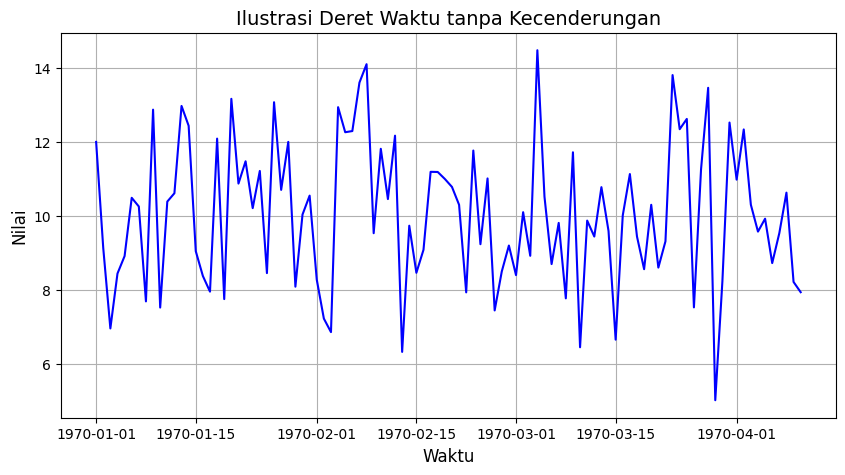

In [103]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

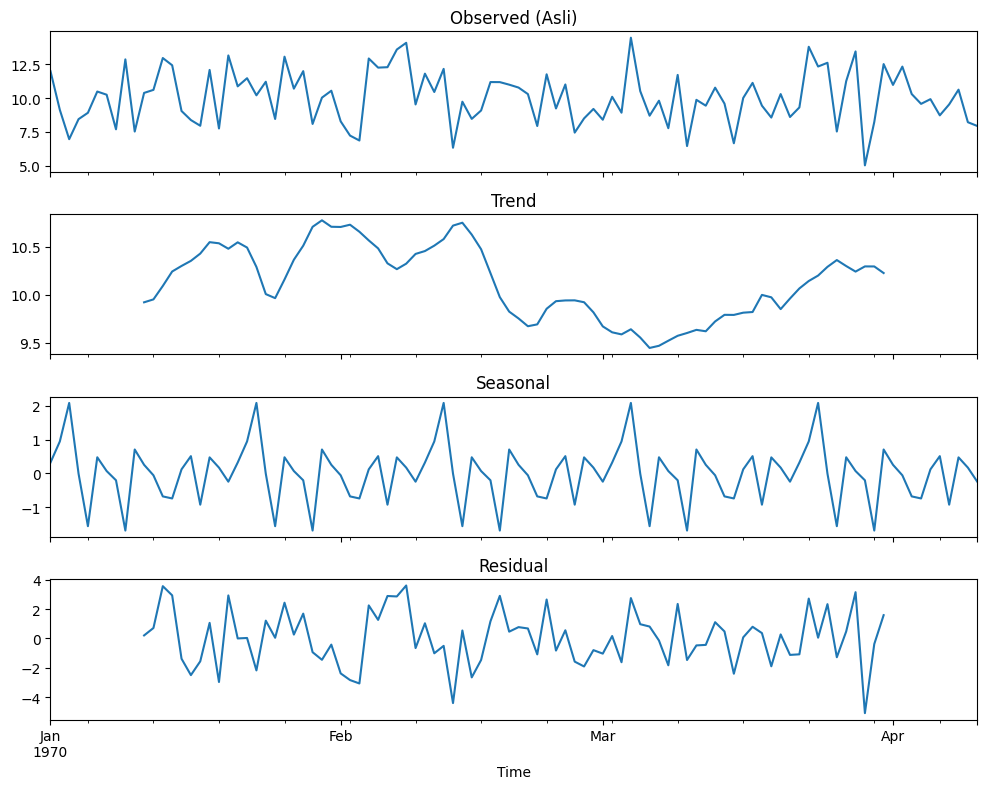

In [104]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

**Jawaban**:
Berdasarkan hasil dekomposisi, deret waktu menunjukkan fluktuasi yang bersifat acak di sekitar nilai rata-rata 10. Pada plot Observed, nilai deret berfluktuasi tanpa menunjukkan kecenderungan meningkat atau menurun secara konsisten serta tidak memperlihatkan pola musiman yang jelas.

Komponen trend terlihat relatif stabil di sekitar nilai 10, meskipun terdapat sedikit perubahan sepanjang periode pengamatan. Perubahan tersebut tidak menunjukkan kecenderungan jangka panjang yang konsisten, sehingga dapat dianggap sebagai fluktuasi akibat sifat acak dari data.

Komponen seasonal menunjukkan pola berulang dengan periode yang ditentukan dalam proses dekomposisi. Namun, pola tersebut tidak dapat diinterpretasikan sebagai pola musiman yang sebenarnya, karena deret awal dibangkitkan tanpa komponen musiman. Pola yang muncul merupakan konsekuensi dari penerapan dekomposisi dengan periode tertentu terhadap data acak.

Sementara itu, komponen residual menunjukkan fluktuasi yang cukup besar dan tidak teratur di sekitar nilai nol. Hal ini menunjukkan bahwa sebagian besar variasi pada deret tidak dapat dijelaskan oleh komponen trend maupun seasonal dan terutama berasal dari galat atau noise acak.

Kesimpulannya, hasil dekomposisi menunjukkan bahwa deret tersebut tidak memiliki tren maupun pola musiman yang nyata. Sebagian besar variasi data berasal dari komponen acak. Oleh karena itu, hasil dekomposisi perlu ditafsirkan secara hati-hati karena penggunaan periode musiman secara paksa pada deret white noise dapat menghasilkan komponen trend dan seasonal yang semu atau tidak memiliki makna substantif.